In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory

# xy grid test 
filexy1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy1m_mb_cartesian.nc'
filexy2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy2m_mb_cartesian.nc'
filexy4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy4m_mb_cartesian.nc'
filexy8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy8m_mb_cartesian.nc'
filexy16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_xy16m_mb_cartesian.nc'

# z grid test
filez1m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z0025m_1m_mb_cartesian.nc'
filez2m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
filez4m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z01m_4m_cartesian.nc'
filez8m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z02m_8m_mb_cartesian.nc'
filez16m = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z04m_16m_mb_cartesian.nc'

files = {
    'xy=1m': filexy1m,
    'xy=2m': filexy2m,
    'xy=4m': filexy4m,
    'xy=8m': filexy8m,
    'xy=16m': filexy16m,
    'z=0.025m_1m' : filez1m,
    'z=0.05m_2m' : filez2m,
    'z=0.1m_4m' : filez4m,
    'z=0.2m_8m' : filez8m,
    'z=0.4m_16m' : filez16m
}

pga_data = [
    ["Driver", 115, -0.9, 171, 1.49, 10.4, 2545, 32, 39, 258],
    ["3-wood", 110, -2.3, 162, 1.47, 9.3, 3663, 29, 44, 228],
    ["5-wood", 106, -2.5, 156, 1.47, 9.7, 4322, 30, 48, 216],
    ["Hybrid", 102, -2.4, 149, 1.47, 10.2, 4587, 28, 49, 211],
    ["3 Iron", 100, -2.5, 145, 1.46, 10.3, 4404, 27, 48, 199],
    ["4 Iron", 98, -2.9, 140, 1.44, 10.8, 4782, 28, 49, 192],
    ["5 Iron", 96, -3.4, 135, 1.41, 11.9, 5280, 30, 50, 182],
    ["6 Iron", 94, -3.7, 130, 1.39, 14.0, 6204, 29, 50, 172],
    ["7 Iron", 92, -3.9, 123, 1.34, 16.1, 7124, 31, 51, 161],
    ["8 Iron", 89, -4.2, 118, 1.33, 17.8, 8078, 30, 51, 150],
    ["9 Iron", 87, -4.3, 112, 1.29, 20.0, 8793, 29, 52, 139],
    ["PW", 84, -4.7, 104, 1.24, 23.7, 9316, 29, 52, 130],
]

lpga_data = [
    ["Driver", 96, 2.8, 143, 1.49, 12.6, 2506, 24, 36, 204],
    ["3-wood", 92, -0.8, 135, 1.47, 11.6, 2595, 23, 38, 183],
    ["5-wood", 90, -1.6, 130, 1.46, 12.3, 4320, 23, 43, 173],
    ["Hybrid", 87, -1.9, 125, 1.44, 13.9, 4504, 23, 45, 163],
    ["4 Iron", 82, -1.7, 118, 1.43, 13.9, 4608, 23, 43, 160],
    ["5 Iron", 81, -2.0, 114, 1.42, 14.6, 4966, 23, 45, 152],
    ["6 Iron", 80, -2.3, 111, 1.41, 16.7, 5904, 23, 46, 142],
    ["7 Iron", 78, -2.5, 106, 1.38, 18.5, 6630, 24, 47, 131],
    ["8 Iron", 76, -2.8, 102, 1.36, 20.8, 7413, 25, 47, 122],
    ["9 Iron", 74, -3.2, 95, 1.30, 23.5, 7605, 25, 48, 112],
    ["PW", 72, -3.2, 88, 1.25, 25.2, 8465, 25, 48, 101],
]

columns = [
    "Club",
    "Club Speed (mph)",
    "Attack Angle (deg)",
    "Ball Speed (mph)",
    "Smash Factor",
    "Launch Angle (deg)",
    "Spin Rate (rpm)",
    "Max Height (m)",
    "Land Angle (deg)",
    "Carry (m)"
]

df_pga = pd.DataFrame(pga_data, columns=columns)
df_lpga = pd.DataFrame(lpga_data, columns=columns)


# convert from mph to m/s
df_pga['Ball Speed (mph)'] = df_pga['Ball Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_pga['Club Speed (mph)'] = df_pga['Club Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_lpga['Ball Speed (mph)'] = df_lpga['Ball Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_lpga['Club Speed (mph)'] = df_lpga['Club Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

display(df_pga)
display(df_lpga)

,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,51.40960,-0.9,76.44384,1.49,10.4,2545,32,39,258
1,3-wood,49.17440,-2.3,72.42048,1.47,9.3,3663,29,44,228
2,5-wood,47.38624,-2.5,69.73824,1.47,9.7,4322,30,48,216
3,Hybrid,45.59808,-2.4,66.60896,1.47,10.2,4587,28,49,211
4,3 Iron,44.70400,-2.5,64.82080,1.46,10.3,4404,27,48,199
5,4 Iron,43.80992,-2.9,62.58560,1.44,10.8,4782,28,49,192
6,5 Iron,42.91584,-3.4,60.35040,1.41,11.9,5280,30,50,182
7,6 Iron,42.02176,-3.7,58.11520,1.39,14.0,6204,29,50,172
8,7 Iron,41.12768,-3.9,54.98592,1.34,16.1,7124,31,51,161
9,8 Iron,39.78656,-4.2,52.75072,1.33,17.8,8078,30,51,150


,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,42.91584,2.8,63.92672,1.49,12.6,2506,24,36,204
1,3-wood,41.12768,-0.8,60.35040,1.47,11.6,2595,23,38,183
2,5-wood,40.23360,-1.6,58.11520,1.46,12.3,4320,23,43,173
3,Hybrid,38.89248,-1.9,55.88000,1.44,13.9,4504,23,45,163
4,4 Iron,36.65728,-1.7,52.75072,1.43,13.9,4608,23,43,160
5,5 Iron,36.21024,-2.0,50.96256,1.42,14.6,4966,23,45,152
6,6 Iron,35.76320,-2.3,49.62144,1.41,16.7,5904,23,46,142
7,7 Iron,34.86912,-2.5,47.38624,1.38,18.5,6630,24,47,131
8,8 Iron,33.97504,-2.8,45.59808,1.36,20.8,7413,25,47,122
9,9 Iron,33.08096,-3.2,42.46880,1.30,23.5,7605,25,48,112



Running club: Driver
  Wind direction: 0 deg
  Wind direction: 20 deg
  Wind direction: 40 deg
  Wind direction: 60 deg
  Wind direction: 80 deg
  Wind direction: 100 deg
  Wind direction: 120 deg
  Wind direction: 140 deg
  Wind direction: 160 deg
  Wind direction: 180 deg

Running club: 3-wood
  Wind direction: 0 deg
  Wind direction: 20 deg
  Wind direction: 40 deg
  Wind direction: 60 deg
  Wind direction: 80 deg
  Wind direction: 100 deg
  Wind direction: 120 deg
  Wind direction: 140 deg
  Wind direction: 160 deg
  Wind direction: 180 deg

Running club: 5-wood
  Wind direction: 0 deg
  Wind direction: 20 deg
  Wind direction: 40 deg
  Wind direction: 60 deg
  Wind direction: 80 deg
  Wind direction: 100 deg
  Wind direction: 120 deg
  Wind direction: 140 deg
  Wind direction: 160 deg
  Wind direction: 180 deg

Running club: Hybrid
  Wind direction: 0 deg
  Wind direction: 20 deg
  Wind direction: 40 deg
  Wind direction: 60 deg
  Wind direction: 80 deg
  Wind direction: 100 deg


,Club,Wind Direction,Grid Type,Grid,dx [m],dy [m],Endpoint Error [m],Percent Error [%],Carry [m],Max Height [m],Lateral [m]
0,Driver,0,XY,xy=1m,0.0000,0.0,0.0000,0.0000,266.2812,29.5979,0.0
1,Driver,0,XY,xy=2m,0.0067,-0.0,0.0067,0.0025,266.2879,29.5974,-0.0
2,Driver,0,XY,xy=4m,0.0130,0.0,0.0130,0.0049,266.2942,29.5963,0.0
3,Driver,0,XY,xy=8m,0.0126,0.0,0.0126,0.0047,266.2938,29.5963,0.0
4,Driver,0,XY,xy=16m,0.0128,0.0,0.0128,0.0048,266.2940,29.5963,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1195,PW,180,Z,z=0.025m_1m,0.0000,0.0,0.0000,0.0000,96.4231,44.0508,0.0
1196,PW,180,Z,z=0.05m_2m,-0.0226,-0.0,0.0226,0.0234,96.4005,44.0545,-0.0
1197,PW,180,Z,z=0.1m_4m,-0.0282,-0.0,0.0282,0.0293,96.3948,44.0557,-0.0
1198,PW,180,Z,z=0.2m_8m,-0.0098,-0.0,0.0098,0.0102,96.4132,44.0534,-0.0



MEAN ERRORS


Endpoint Error [m]  Percent Error [%]
Grid Type Grid       Wind Direction                                       
XY        xy=16m     0                           0.0101             0.0047
                     20                          0.0655             0.0293
                     40                          0.0536             0.0277
                     60                          0.0168             0.0080
                     80                          0.0306             0.0157
...                                                 ...                ...
Z         z=0.4m_16m 100                         0.0934             0.0496
                     120                         0.1262             0.0722
                     140                         0.1253             0.0776
                     160                         0.1227             0.0815
                     180                         0.1344             0.0916

[100 rows x 2 columns]

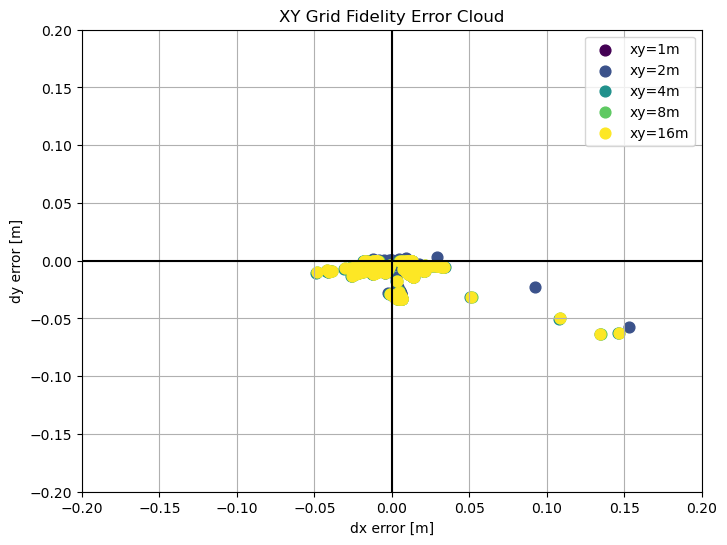

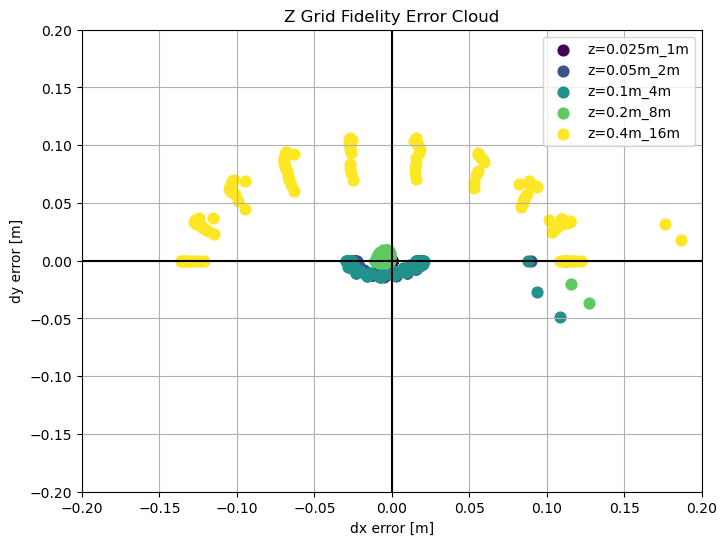

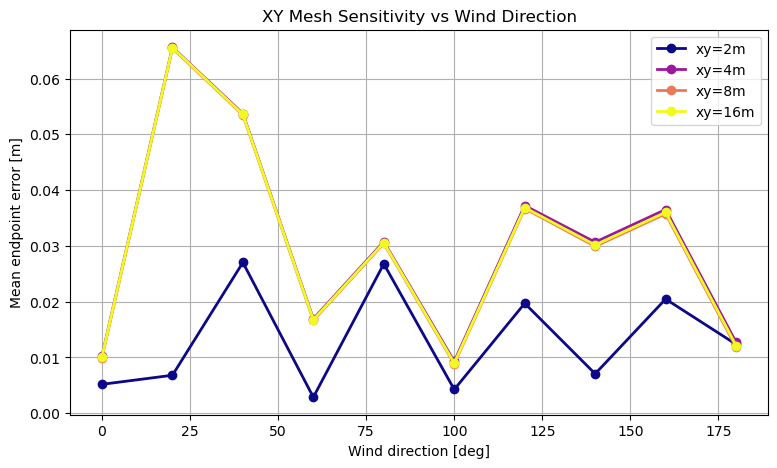

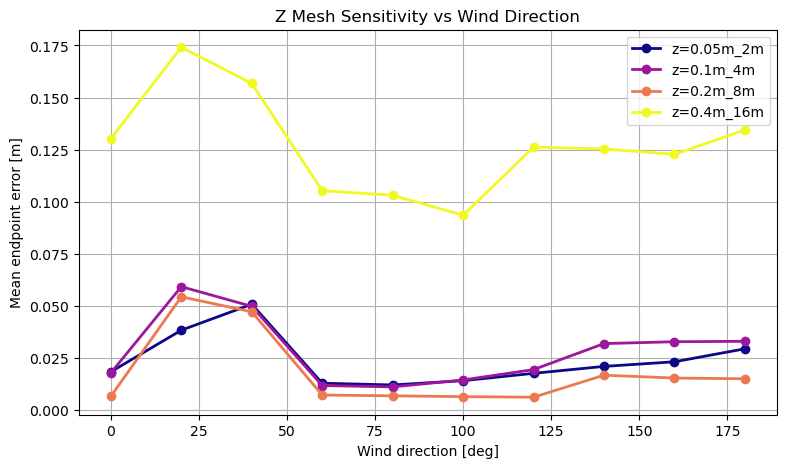

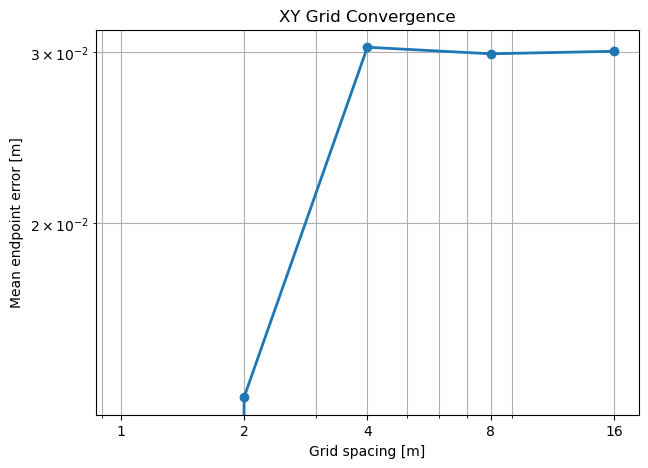

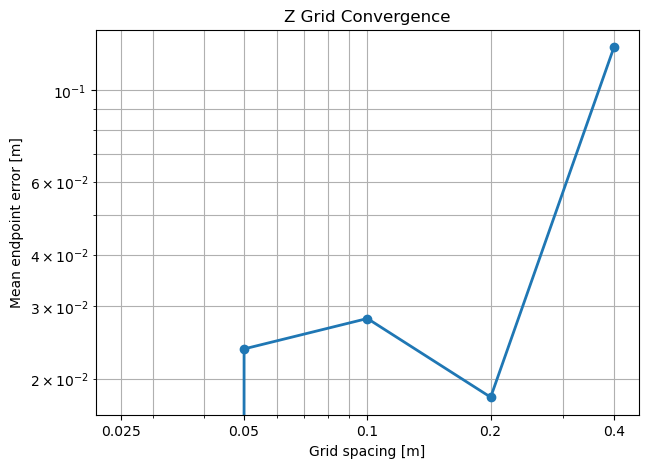

In [3]:
# xy1m and z0_0.025m_1m reference
# ============================================================
# GLOBAL SETTINGS
# ============================================================

dt = 0.01
solver = 'euler'
#rtol = 1e-10

spin_axis = 0
r = 150

# ============================================================
# GRID FILES
# ============================================================

xy_keys = [
    'xy=1m',
    'xy=2m',
    'xy=4m',
    'xy=8m',
    'xy=16m'
]

z_keys = [
    'z=0.025m_1m',
    'z=0.05m_2m',
    'z=0.1m_4m',
    'z=0.2m_8m',
    'z=0.4m_16m'
]

# ============================================================
# WIND DIRECTIONS
# ============================================================

wind_directions = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]

# 0   = tailwind
# 180 = headwind
# 90  = crosswind

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_rotated_geometry(direction, r=r):

    theta = np.deg2rad(direction)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r

    P0_new = np.array([x, y, 0])

    orientation_new = direction

    return P0_new, orientation_new


def transform_to_local_frame(p, direction):

    P0_used, _ = get_rotated_geometry(direction)

    theta = np.deg2rad(direction)

    xt = p[:, 0] - P0_used[0]
    yt = p[:, 1] - P0_used[1]

    x_local = xt * np.cos(theta) + yt * np.sin(theta)
    y_local = -xt * np.sin(theta) + yt * np.cos(theta)

    z_local = p[:, 2]

    return np.column_stack((x_local, y_local, z_local))

# ============================================================
# ERROR METRICS
# ============================================================

def endpoint_error(ref_p, test_p):

    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]

    return np.sqrt(dx**2 + dy**2)


def percent_error(ref_p, test_p):

    ref_distance = np.linalg.norm(
        ref_p[-1, :2] - ref_p[0, :2]
    )

    return endpoint_error(ref_p, test_p) / ref_distance * 100


def x_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]


def y_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]


def carry_distance(p):
    return p[-1, 0] - p[0, 0]


def max_height(p):
    return np.max(p[:, 2])


def lateral_distance(p):
    return p[-1, 1] - p[0, 1]

# ============================================================
# TRAJECTORY SOLVER
# ============================================================

def solve_trajectory(
    file,
    shot_speed,
    shot_angle,
    shot_spin,
    direction
):

    P0_used, orientation_used = get_rotated_geometry(direction)

    wind = WindField(
        profile='rans',
        ds=file
    )

    traj = Trajectory(

        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,

        wind=wind,

        orientation=orientation_used,
        P0=P0_used
    )

    traj.solve(
        solver=solver,
        dt=dt
    )

    return traj.p

# ============================================================
# PGA PARAMETRIC STUDY
# ============================================================

all_results = []

for idx, row in df_pga.iterrows():

    club = row['Club']

    shot_speed = row['Ball Speed (m/s)']
    shot_angle = row['Launch Angle (deg)']
    shot_spin = row['Spin Rate (rpm)']

    print(f'\nRunning club: {club}')

    # ========================================================
    # LOOP OVER WIND DIRECTIONS
    # ========================================================

    for direction in wind_directions:

        print(f'  Wind direction: {direction} deg')

        trajectories = {}

        # ====================================================
        # SOLVE ALL GRID CASES
        # ====================================================

        for key, file in files.items():

            p = solve_trajectory(

                file=file,

                shot_speed=shot_speed,
                shot_angle=shot_angle,
                shot_spin=shot_spin,
                direction=direction
            )

            trajectories[key] = p

        # ====================================================
        # XY GRID ANALYSIS
        # ====================================================

        ref_xy = transform_to_local_frame(
            trajectories['xy=1m'],
            direction
        )

        for key in xy_keys:

            test_p = transform_to_local_frame(
                trajectories[key],
                direction
            )

            all_results.append({

                'Club': club,
                'Wind Direction': direction,

                'Grid Type': 'XY',
                'Grid': key,

                'dx [m]':
                    x_error(ref_xy, test_p),

                'dy [m]':
                    y_error(ref_xy, test_p),

                'Endpoint Error [m]':
                    endpoint_error(ref_xy, test_p),

                'Percent Error [%]':
                    percent_error(ref_xy, test_p),

                'Carry [m]':
                    carry_distance(test_p),

                'Max Height [m]':
                    max_height(test_p),

                'Lateral [m]':
                    lateral_distance(test_p)
            })

        # ====================================================
        # Z GRID ANALYSIS
        # ====================================================

        ref_z = transform_to_local_frame(
            trajectories['z=0.025m_1m'],
            direction
        )

        for key in z_keys:

            test_p = transform_to_local_frame(
                trajectories[key],
                direction
            )

            all_results.append({

                'Club': club,
                'Wind Direction': direction,

                'Grid Type': 'Z',
                'Grid': key,

                'dx [m]':
                    x_error(ref_z, test_p),

                'dy [m]':
                    y_error(ref_z, test_p),

                'Endpoint Error [m]':
                    endpoint_error(ref_z, test_p),

                'Percent Error [%]':
                    percent_error(ref_z, test_p),

                'Carry [m]':
                    carry_distance(test_p),

                'Max Height [m]':
                    max_height(test_p),

                'Lateral [m]':
                    lateral_distance(test_p)
            })

# ============================================================
# CREATE DATAFRAME
# ============================================================

df_results = pd.DataFrame(all_results)

print('\n===================================================')
print('SIMULATION COMPLETE')
print('===================================================')

display(df_results.round(4))

# ============================================================
# SUMMARY TABLE
# ============================================================

summary = df_results.groupby(
    ['Grid Type', 'Grid', 'Wind Direction']
)[
    ['Endpoint Error [m]', 'Percent Error [%]']
].mean()

print('\n===================================================')
print('MEAN ERRORS')
print('===================================================')

display(summary.round(4))

# ============================================================
# PLOT 1 — ERROR CLOUDS
# ============================================================

for grid_type in ['XY', 'Z']:

    plt.figure(figsize=(8, 6))

    subset = df_results[
        df_results['Grid Type'] == grid_type
    ]

    grids = subset['Grid'].unique()

    colors = plt.cm.viridis(
        np.linspace(0, 1, len(grids))
    )

    for i, grid in enumerate(grids):

        data = subset[
            subset['Grid'] == grid
        ]

        plt.scatter(

            data['dx [m]'],
            data['dy [m]'],

            s=60,

            color=colors[i],

            label=grid
        )

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.xlim(-0.2, 0.2)
    plt.ylim(-0.2, 0.2)
    plt.xlabel('dx error [m]')
    plt.ylabel('dy error [m]')

    plt.title(
        f'{grid_type} Grid Fidelity Error Cloud'
    )

    plt.grid(True)
    plt.legend()

    plt.show()

# ============================================================
# PLOT 2 — WIND DIRECTION SENSITIVITY
# ============================================================

for grid_type in ['XY', 'Z']:

    plt.figure(figsize=(9, 5))

    subset = df_results[
        df_results['Grid Type'] == grid_type
    ]

    grids = subset['Grid'].unique()[1:]

    colors = plt.cm.plasma(
        np.linspace(0, 1, len(grids))
    )

    for i, grid in enumerate(grids):

        data = subset[
            subset['Grid'] == grid
        ]

        grouped = data.groupby(
            'Wind Direction'
        )['Endpoint Error [m]'].mean()

        plt.plot(

            grouped.index,
            grouped.values,

            marker='o',
            linewidth=2,

            color=colors[i],

            label=grid
        )

    plt.xlabel('Wind direction [deg]')
    plt.ylabel('Mean endpoint error [m]')

    plt.title(
        f'{grid_type} Mesh Sensitivity vs Wind Direction'
    )

    plt.grid(True)
    plt.legend()

    plt.show()
# ============================================================
# PLOT 3 — CONVERGENCE PLOTS
# ============================================================

xy_spacing = np.array([1, 2, 4, 8, 16])
z_spacing = np.array([0.025, 0.05, 0.1, 0.2, 0.4])

for grid_type, spacing, keys in zip(

    ['XY', 'Z'],
    [xy_spacing, z_spacing],
    [xy_keys, z_keys]
):

    plt.figure(figsize=(7, 5))

    means = []

    for key in keys:

        value = df_results[
            (df_results['Grid'] == key)
        ]['Endpoint Error [m]'].mean()

        means.append(value)

    plt.loglog(
        spacing,
        means,

        marker='o',
        linewidth=2
    )

    plt.xlabel('Grid spacing [m]')
    plt.ylabel('Mean endpoint error [m]')
    plt.xticks(spacing, labels=[str(s) for s in spacing])

    plt.title(
        f'{grid_type} Grid Convergence'
    )

    plt.grid(True, which='both')

    plt.show()

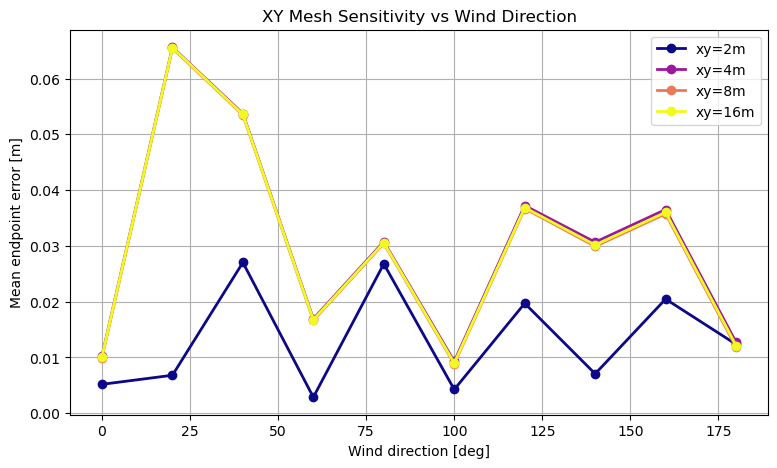

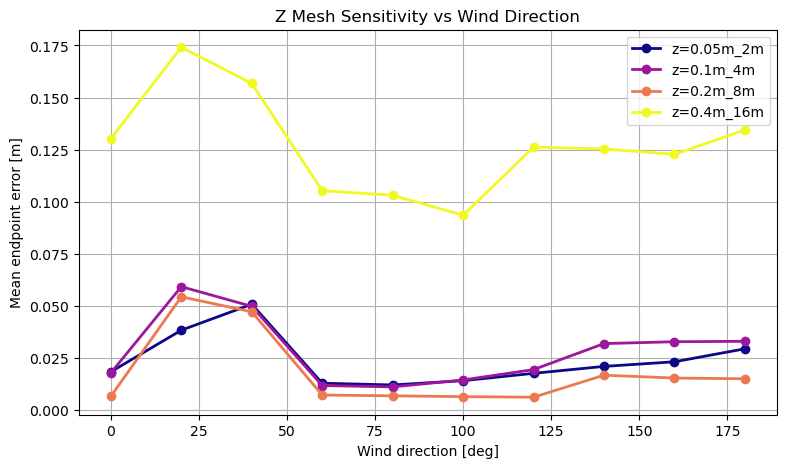

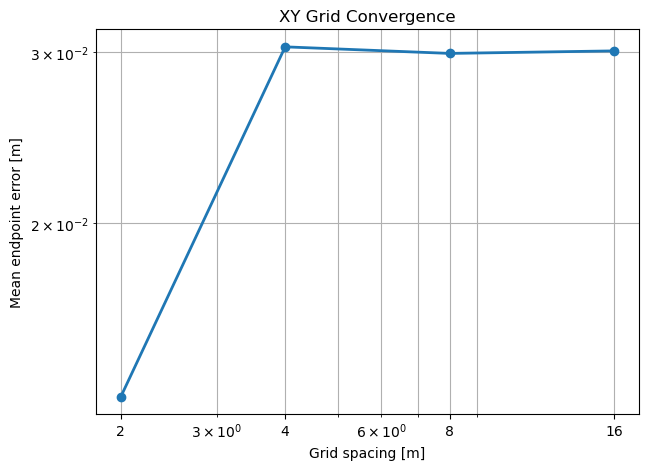

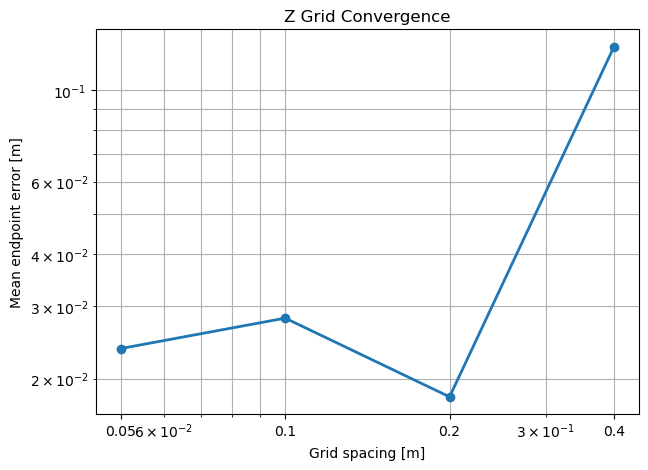

In [4]:
# ============================================================
# REFERENCE GRIDS
# ============================================================

reference_grids = {
    'XY': 'xy=1m',
    'Z': 'z=0.025m_1m'
}

# ============================================================
# PLOT 2 — WIND DIRECTION SENSITIVITY
# ============================================================

for grid_type in ['XY', 'Z']:

    plt.figure(figsize=(9, 5))

    subset = df_results[
        df_results['Grid Type'] == grid_type
    ]

    # Exclude reference grid safely
    grids = [

        g for g in subset['Grid'].unique()

        if g != reference_grids[grid_type]
    ]

    colors = plt.cm.plasma(
        np.linspace(0, 1, len(grids))
    )

    for i, grid in enumerate(grids):

        data = subset[
            subset['Grid'] == grid
        ]

        grouped = data.groupby(
            'Wind Direction'
        )['Endpoint Error [m]'].mean()

        plt.plot(

            grouped.index,
            grouped.values,

            marker='o',
            linewidth=2,

            color=colors[i],

            label=grid
        )

    plt.xlabel('Wind direction [deg]')
    plt.ylabel('Mean endpoint error [m]')

    plt.title(
        f'{grid_type} Mesh Sensitivity vs Wind Direction'
    )

    plt.grid(True)
    plt.legend()

    plt.show()

# ============================================================
# PLOT 3 — CONVERGENCE PLOTS
# ============================================================

xy_spacing = np.array([1, 2, 4, 8, 16])
z_spacing  = np.array([0.025, 0.05, 0.1, 0.2, 0.4])

spacing_lookup = {

    'XY': dict(zip(xy_keys, xy_spacing)),
    'Z':  dict(zip(z_keys,  z_spacing))
}

for grid_type, keys in zip(

    ['XY', 'Z'],
    [xy_keys, z_keys]
):

    plt.figure(figsize=(7, 5))

    # Remove reference grid
    filtered_keys = [

        k for k in keys

        if k != reference_grids[grid_type]
    ]

    spacings = [
        spacing_lookup[grid_type][k]
        for k in filtered_keys
    ]

    means = []

    for key in filtered_keys:

        value = df_results[
            df_results['Grid'] == key
        ]['Endpoint Error [m]'].mean()

        means.append(value)

    plt.loglog(

        spacings,
        means,

        marker='o',
        linewidth=2
    )

    plt.xlabel('Grid spacing [m]')
    plt.ylabel('Mean endpoint error [m]')

    plt.xticks(
        spacings,
        labels=[str(s) for s in spacings]
    )

    plt.title(
        f'{grid_type} Grid Convergence'
    )

    plt.grid(True, which='both')

    plt.show()